[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/16-correlacao/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/16-correlacao")
    print("Material preparado em:", Path.cwd())


# Correlação com despesas médicas

Material de estudo da Aula 16

# Objetivos

Este material usa a base **Medical Insurance Cost** para estudar
associação entre variáveis quantitativas. Ao final, você deve conseguir:

1.  calcular e interpretar covariância e correlação de Pearson;
2.  explicar por que Pearson está entre $-1$ e $1$;
3.  comparar Pearson e Spearman;
4.  reconhecer não linearidade, pontos influentes e restrição de
    amplitude;
5.  distinguir correlação marginal e condicional;
6.  quantificar a incerteza de uma correlação amostral.

## Como estudar este capítulo

O fio condutor é uma pergunta simples: **quando duas variáveis mudam
juntas, como podemos descrever esse padrão sem confundir associação com
causalidade?** Começaremos pelo gráfico de dispersão, porque um único
coeficiente nunca conta toda a história. Em seguida, construiremos
covariância, Pearson e Spearman a partir daquilo que se observa no
gráfico.

Leia cada bloco nesta ordem: primeiro identifique a pergunta, depois
examine a figura ou a tabela, tente antecipar o resultado e somente
então abra o código. O código registra como a análise foi produzida; a
interpretação explica o que ela permite concluir. Ao final, você deve
conseguir escolher uma medida de associação, reconhecer situações em que
ela engana e redigir uma conclusão compatível com os dados.

# 1. Obtenção e preparação da base

A base está disponível no Kaggle sob licença CC0. Cada linha representa
uma pessoa segurada. Para tornar o material reproduzível também sem
rede, o repositório contém uma cópia local do arquivo usado na aula.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

local_file = Path("data/insurance.csv")
if local_file.exists():
    csv_path = local_file
else:
    import kagglehub
    path = kagglehub.dataset_download(
        "mosapabdelghany/medical-insurance-cost-dataset"
    )
    csv_path = next(Path(path).rglob("*.csv"))

df = pd.read_csv(csv_path)
df.head()

> **Interpretação**
>
> As primeiras linhas confirmam a granularidade: uma pessoa por
> registro. `charges` é uma despesa observada, não um preço causalmente
> determinado apenas pelas demais colunas.

# 2. O que é a base?

As principais colunas são:

| coluna     | tipo               | significado                       |
|------------|--------------------|-----------------------------------|
| `age`      | numérica discreta  | idade em anos                     |
| `sex`      | categórica nominal | sexo registrado                   |
| `bmi`      | numérica contínua  | índice de massa corporal em kg/m² |
| `children` | numérica discreta  | dependentes cobertos              |
| `smoker`   | categórica nominal | tabagismo                         |
| `region`   | categórica nominal | região dos Estados Unidos         |
| `charges`  | numérica contínua  | despesas médicas cobradas em US\$ |

In [ ]:
print("Dimensão:", df.shape)
print("Ausências por coluna:")
print(df.isna().sum())
print("Linhas duplicadas:", df.duplicated().sum())

> **Interpretação**
>
> Não há ausências, mas existe uma linha duplicada exata. Como não há
> identificador individual, não é possível concluir se ela é erro ou
> duas pessoas com os mesmos atributos. Mantê-la tem impacto
> desprezível; removê-la exigiria documentar essa decisão.

# 3. Análise descritiva

In [ ]:
df.describe(percentiles=[.05, .25, .50, .75, .95]).round(2)

In [ ]:
df.groupby("smoker").agg(
    pessoas=("charges", "size"),
    idade_média=("age", "mean"),
    imc_médio=("bmi", "mean"),
    despesa_média=("charges", "mean"),
    despesa_mediana=("charges", "median"),
).round(2)

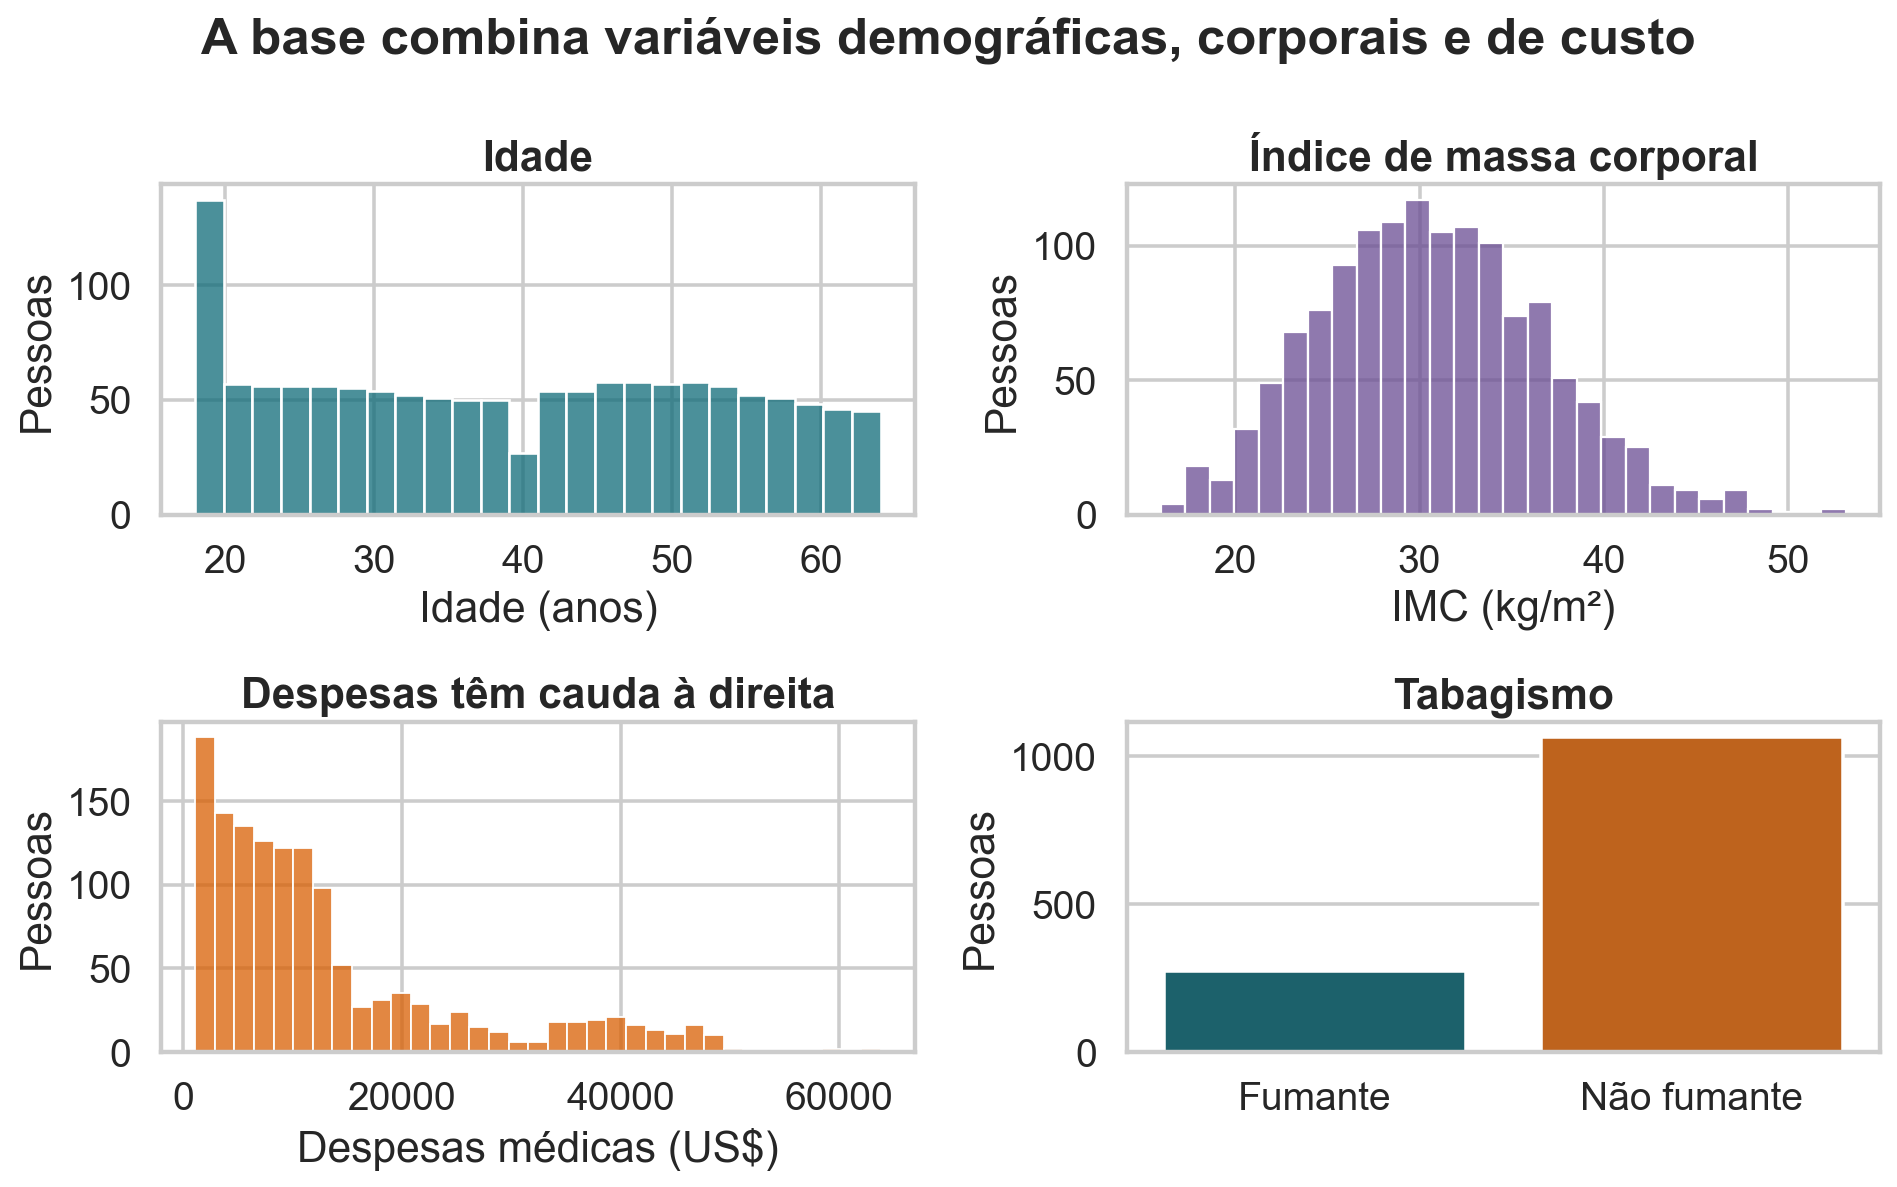

> **Interpretação**
>
> As despesas apresentam forte assimetria à direita e diferem
> substancialmente entre fumantes e não fumantes. Isso antecipa duas
> precauções: Pearson pode ser sensível aos maiores valores e uma
> correlação global pode misturar grupos com níveis e relações
> distintos.

# 4. Comece pelo gráfico de dispersão

In [ ]:
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=.6)
plt.xlabel("Idade (anos)")
plt.ylabel("Despesas médicas (US$)")
plt.show()

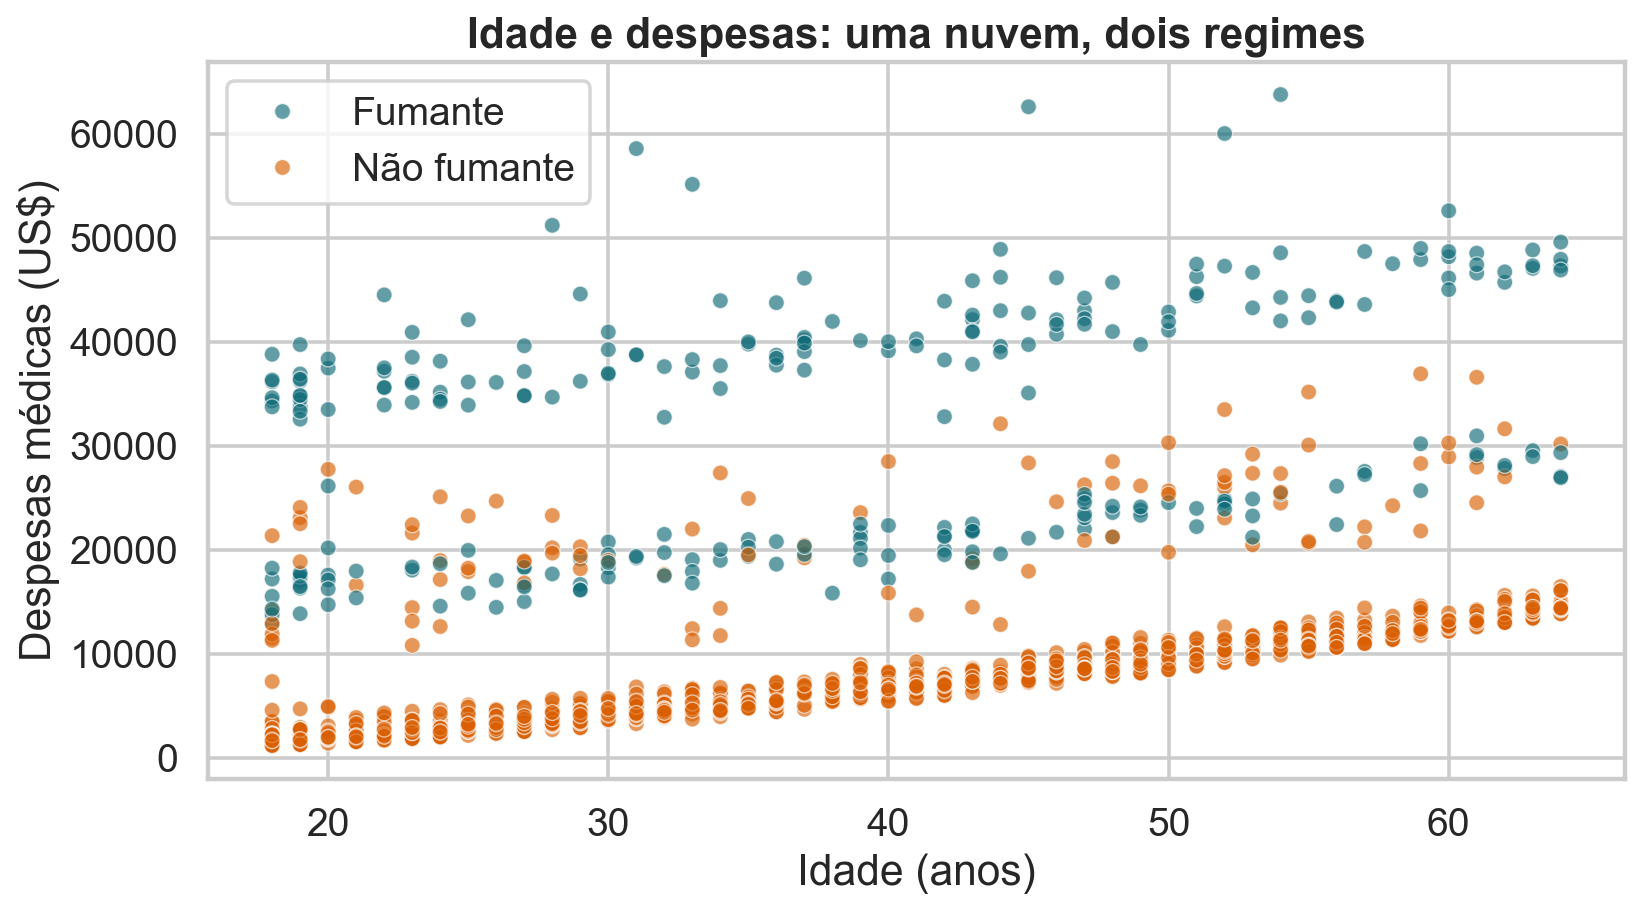

> **Interpretação**
>
> A despesa tende a aumentar com a idade, porém o grupo de fumantes
> ocupa um patamar muito mais alto. Uma única reta para todos os pontos
> descreve apenas uma média entre mecanismos heterogêneos.

# 5. Da variância à covariância

Para uma amostra $x_1,\ldots,x_n$, a variância amostral é

$$
s_X^2=\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2.
$$

Aqui, $n$ é o número de observações, $x_i$ é a observação $i$, $\bar x$
é a média amostral e $x_i-\bar x$ é seu desvio. O denominador $n-1$
aparece porque os desvios somam zero: depois de fixar $n-1$ deles, o
último está determinado.

Para duas variáveis, multiplicamos os desvios correspondentes:

$$
s_{XY}=\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y).
$$

Os termos têm a seguinte leitura:

- $s_{XY}$: covariância amostral entre $X$ e $Y$;
- $x_i-\bar x$: desvio horizontal do ponto em relação à média de $X$;
- $y_i-\bar y$: desvio da segunda variável;
- produto positivo: os desvios têm o mesmo sinal;
- produto negativo: os desvios têm sinais opostos.

Geometricamente, as retas $x=\bar x$ e $y=\bar y$ dividem a dispersão em
quatro quadrantes:

| posição do ponto  | $x_i-\bar x$ | $y_i-\bar y$ | contribuição |
|-------------------|:------------:|:------------:|:------------:|
| superior direito  |     $+$      |     $+$      |     $+$      |
| superior esquerdo |     $-$      |     $+$      |     $-$      |
| inferior esquerdo |     $-$      |     $-$      |     $+$      |
| inferior direito  |     $+$      |     $-$      |     $-$      |

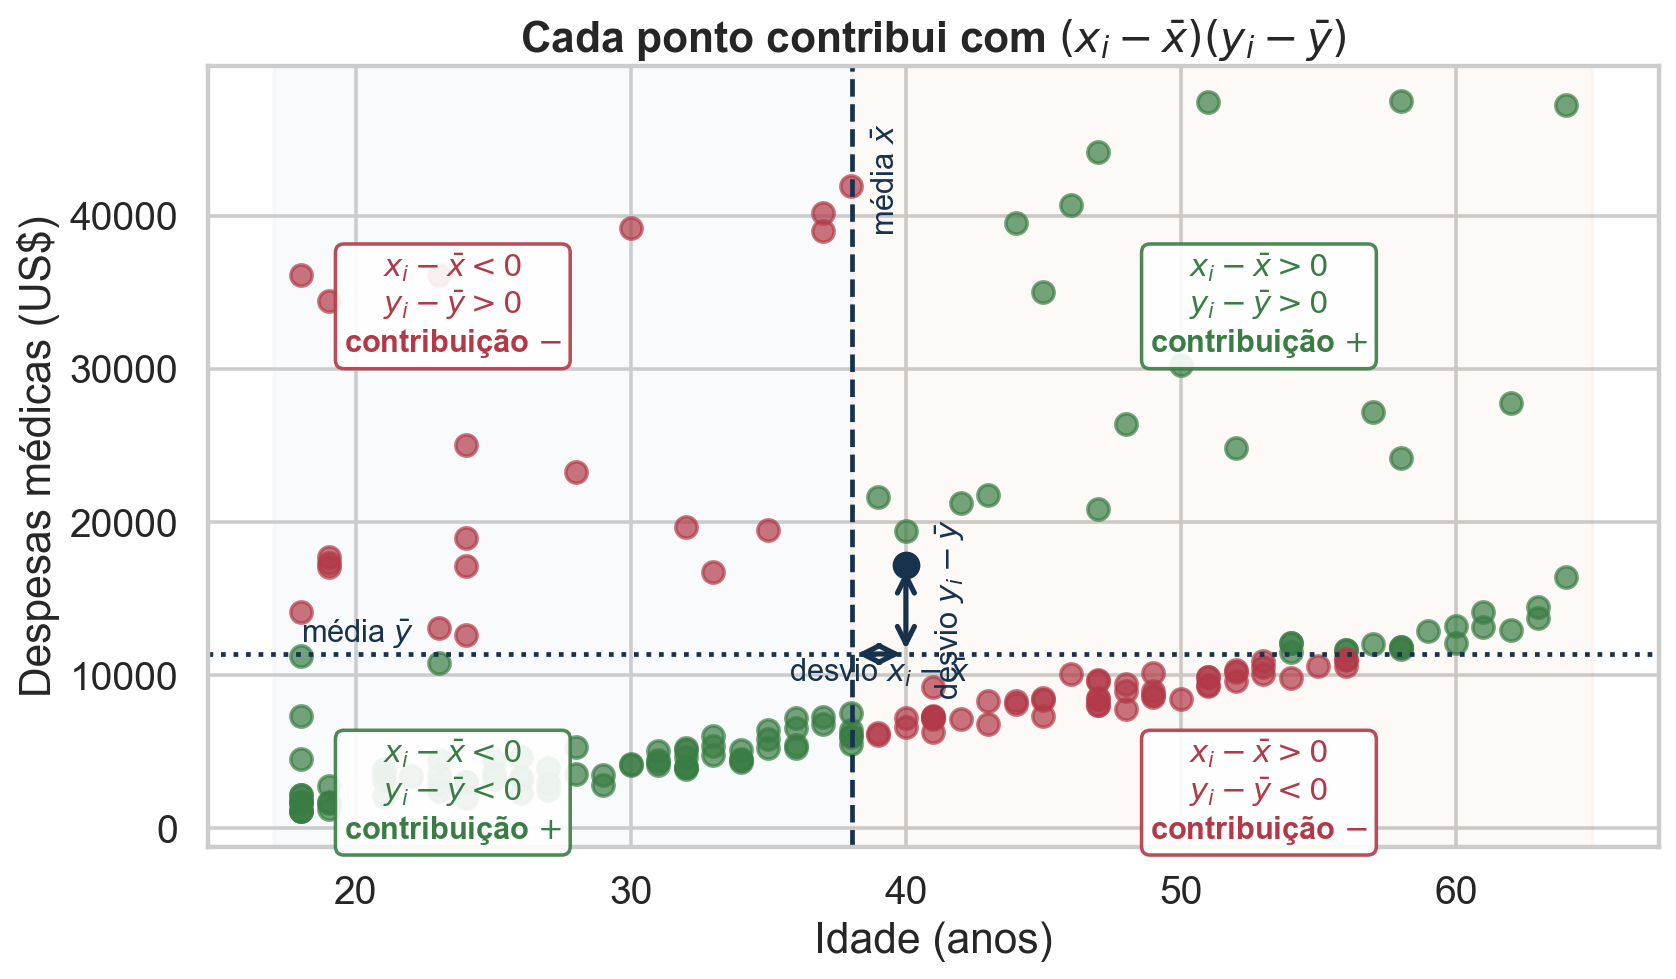

Os quadrantes diagonais contribuem positivamente porque multiplicam
desvios de mesmo sinal; os outros dois contribuem negativamente. A
covariância é o saldo dessas contribuições, dividido por $n-1$.

In [ ]:
x = np.array([1., 2., 3.])
y = np.array([2., 1., 5.])
products = (x-x.mean())*(y-y.mean())
print("Produtos dos desvios:", products)
print("Soma:", products.sum())
print("Covariância amostral:", products.sum()/(len(x)-1))

> **Interpretação**
>
> Os produtos positivos dominam e a covariância vale 1,5. O sinal é
> interpretável, mas a magnitude ainda depende das unidades de $X$ e
> $Y$.

# 6. Correlação de Pearson

Pearson normaliza a covariância pelos desvios-padrão:

$$
r_{XY}=\frac{s_{XY}}{s_Xs_Y}
=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_i(x_i-\bar x)^2}\sqrt{\sum_i(y_i-\bar y)^2}}.
$$

O numerador mede variação conjunta. Os dois fatores no denominador medem
o comprimento dos vetores centrados e retiram as unidades. Por isso $r$
é adimensional.

In [ ]:
def pearson_manual(x, y):
    xc = np.asarray(x)-np.mean(x)
    yc = np.asarray(y)-np.mean(y)
    return np.sum(xc*yc)/np.sqrt(np.sum(xc**2)*np.sum(yc**2))

print("Manual:", pearson_manual(x, y))
print("NumPy: ", np.corrcoef(x, y)[0, 1])

## 6.1 Por que Pearson está entre -1 e 1?

Com $\mathbf{x}_c=(x_1-\bar x,\ldots,x_n-\bar x)$ e definição análoga
para $\mathbf{y}_c$:

$$
r=\frac{\mathbf{x}_c^\top\mathbf{y}_c}
{\|\mathbf{x}_c\|\,\|\mathbf{y}_c\|}.
$$

A desigualdade de Cauchy–Schwarz afirma

$$
|\mathbf{x}_c^\top\mathbf{y}_c|
\leq\|\mathbf{x}_c\|\,\|\mathbf{y}_c\|.
$$

Dividindo ambos os lados pelo produto positivo das normas, obtemos
$|r|\leq1$. Geometricamente, $r$ é o cosseno do ângulo entre os vetores
centrados.

## 6.2 Pearson como média de produtos padronizados

Defina

$$
z_{xi}=\frac{x_i-\bar x}{s_X},\qquad
z_{yi}=\frac{y_i-\bar y}{s_Y}.
$$

Então

$$
r=\frac{1}{n-1}\sum_{i=1}^n z_{xi}z_{yi}.
$$

Cada parcela mede se a observação está simultaneamente acima ou abaixo
das duas médias, agora em unidades comparáveis de desvio-padrão.

# 7. Pearson na base de seguros

In [ ]:
numeric = df[["age", "bmi", "children", "charges"]]
numeric.corr().round(3)

In [ ]:
r_age = pearsonr(df["age"], df["charges"])
print(f"Pearson idade-despesas: r={r_age.statistic:.3f}")

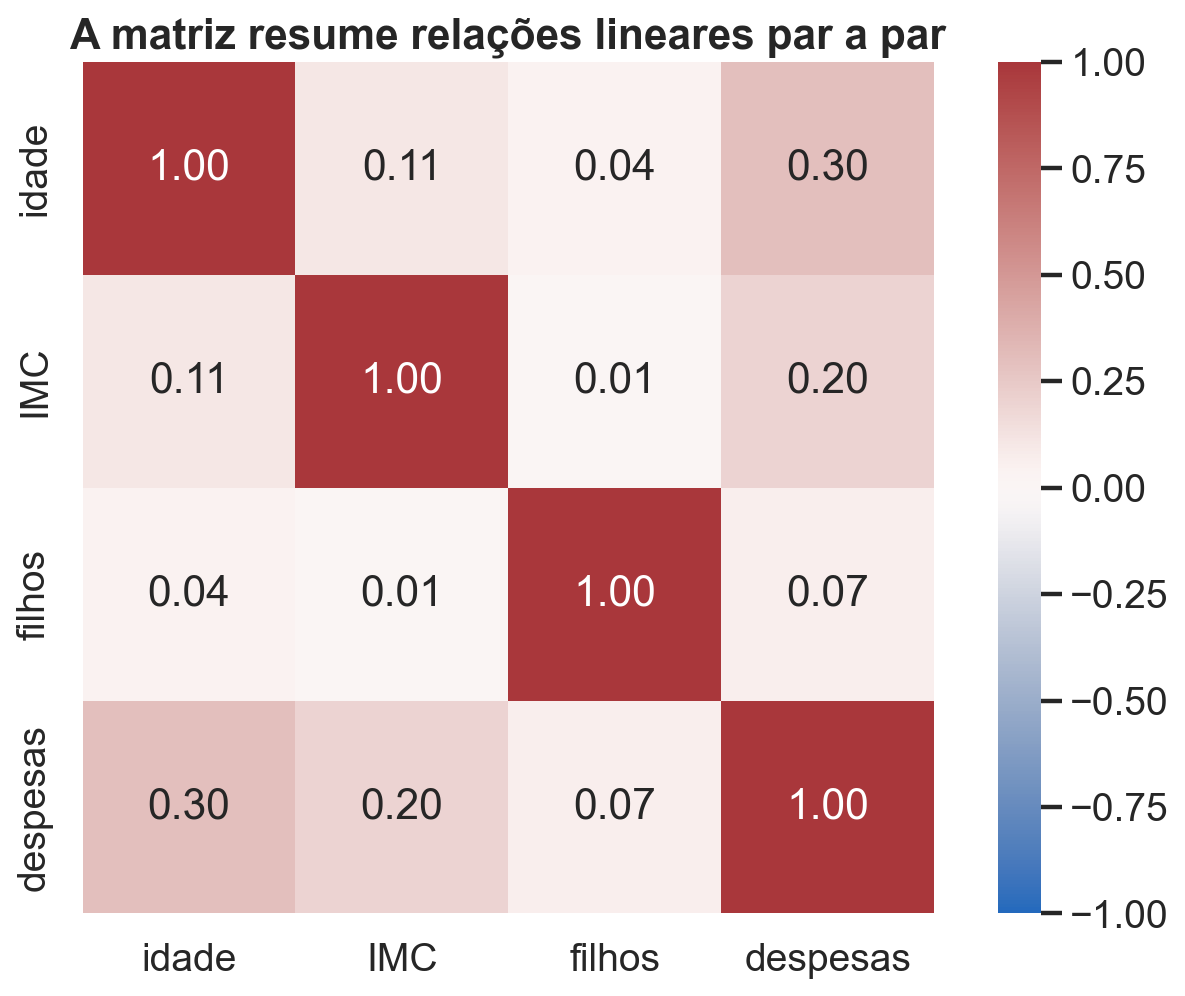

> **Interpretação**
>
> Idade e despesas têm associação linear positiva, mas modesta
> ($r\approx0,30$). O coeficiente não diz que envelhecer causa sozinho o
> aumento observado, nem controla tabagismo, IMC ou acesso aos serviços
> de saúde.

# 8. Pearson pode perder relações não lineares

In [ ]:
rng = np.random.default_rng(1616)
x_curve = np.linspace(-3, 3, 250)
y_curve = x_curve**2 + rng.normal(0, .45, len(x_curve))
print("Pearson:", pearsonr(x_curve, y_curve)[0])
sns.scatterplot(x=x_curve, y=y_curve)
plt.show()

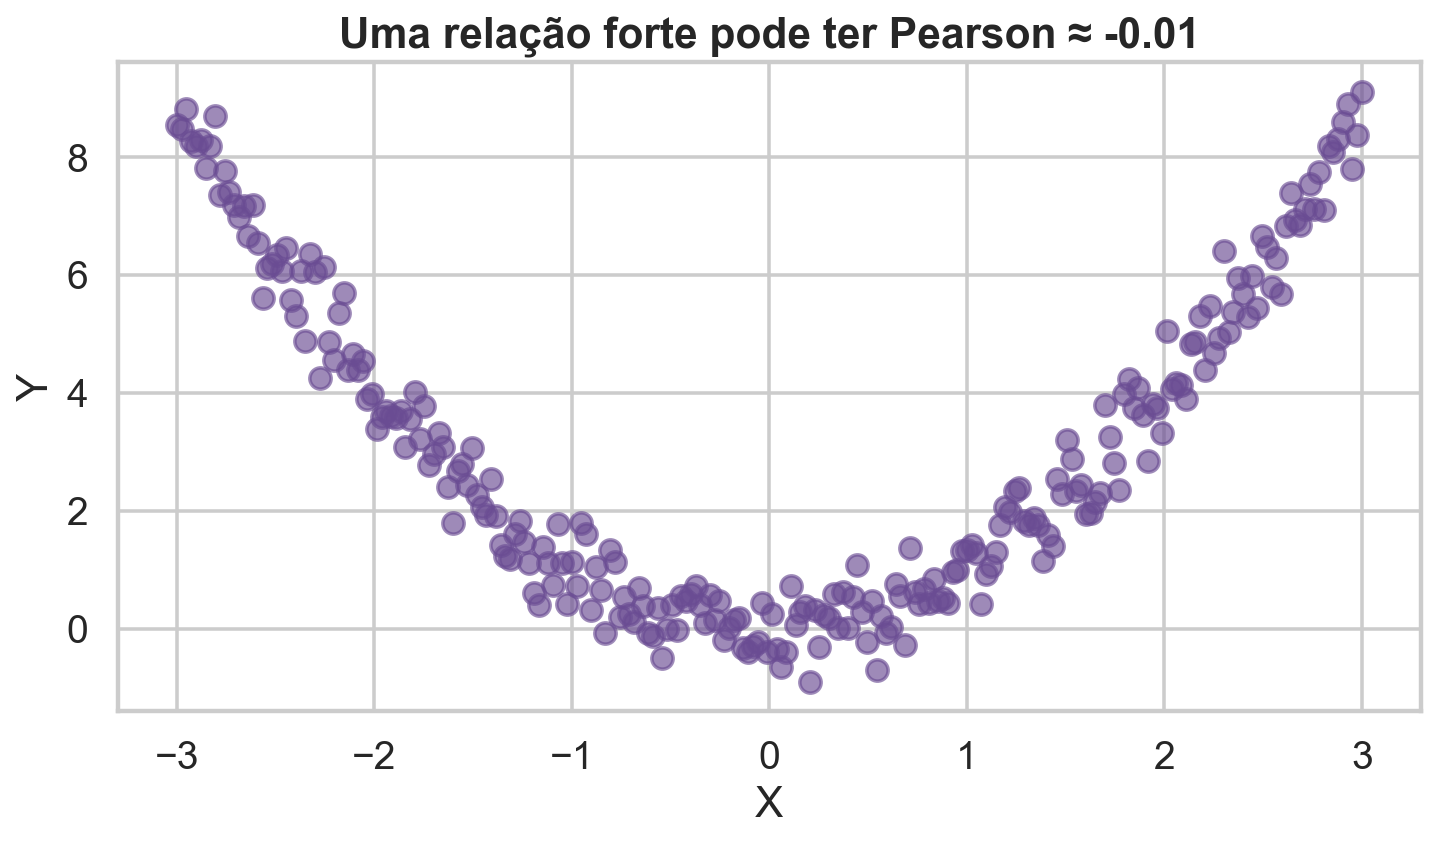

> **Interpretação**
>
> A relação é forte e previsível, mas não linear: o crescimento no braço
> direito é compensado pela queda no braço esquerdo. Pearson próximo de
> zero significa ausência de componente linear média, não ausência de
> dependência.

# 9. Correlação de Spearman

Spearman aplica Pearson aos postos:

$$
r_S=\operatorname{cor}(R_X,R_Y),
$$

em que $R_X$ e $R_Y$ são os vetores de postos das observações. Um
**posto** é a posição ocupada por um valor depois que a variável é
ordenada do menor para o maior. Portanto, se
$R_i=\operatorname{rank}(x_i)$ e $S_i=\operatorname{rank}(y_i)$,
Spearman é a correlação de Pearson entre $(R_1,\ldots,R_n)$ e
$(S_1,\ldots,S_n)$.

Ele mede associação monotônica e não exige que a variação siga uma reta.

## 9.1 Exemplo didático sem empates

Considere quatro pares:

| pessoa $i$ | $x_i$ | $R_i$ | $y_i$ | $S_i$ | $d_i=R_i-S_i$ | $d_i^2$ |
|-----------:|------:|------:|------:|------:|--------------:|--------:|
|          1 |    10 |     1 |    12 |     2 |            −1 |       1 |
|          2 |    20 |     2 |     8 |     1 |             1 |       1 |
|          3 |    30 |     3 |    15 |     3 |             0 |       0 |
|          4 |    40 |     4 |    20 |     4 |             0 |       0 |

Os postos de $X$ são $(1,2,3,4)$. Para $Y$, o menor valor é 8, seguido
por 12, 15 e 20; seus postos na ordem original são $(2,1,3,4)$.
Definindo $d_i=R_i-S_i$, obtemos $\sum_i d_i^2=2$.

Sem empates, a correlação de Spearman também pode ser escrita como

$$
r_S=1-\frac{6\sum_{i=1}^{n}d_i^2}{n(n^2-1)}.
$$

Nessa expressão, $n$ é o número de pares, $d_i$ é a diferença entre os
dois postos da observação $i$ e $\sum_i d_i^2$ mede o desacordo total
entre as duas ordenações. Para o exemplo:

$$
r_S=1-\frac{6\cdot2}{4(4^2-1)}
=1-\frac{12}{60}=0{,}80.
$$

In [ ]:
x_example = np.array([10, 20, 30, 40])
y_example = np.array([12, 8, 15, 20])
ranks_x = pd.Series(x_example).rank(method="average")
ranks_y = pd.Series(y_example).rank(method="average")

example = pd.DataFrame({
    "x": x_example,
    "R": ranks_x,
    "y": y_example,
    "S": ranks_y,
})
example["d"] = example["R"]-example["S"]
example["d²"] = example["d"]**2
print(example)
print("Spearman pela fórmula:", 1-6*example["d²"].sum()/(4*(4**2-1)))
print("Spearman pelo SciPy:", spearmanr(x_example, y_example)[0])

> **Interpretação**
>
> O valor 0,80 é alto porque as ordenações quase coincidem. A única
> discordância é a inversão entre as duas primeiras pessoas; se todos os
> postos fossem iguais, $\sum_i d_i^2=0$ e $r_S=1$.

## 9.2 Empates recebem postos médios

Quando há empates, cada observação recebe o posto médio das posições que
ocuparia. Por exemplo, $(18,18,19,21)$ recebe postos
$(1{,}5,1{,}5,3,4)$.

Nesse caso, a forma segura é calcular $r_S=\operatorname{cor}(R_X,R_Y)$
diretamente. A fórmula abreviada baseada em $\sum_i d_i^2$ pressupõe
ausência de empates; sem a correção apropriada, ela não deve ser usada.

In [ ]:
pearson_age = pearsonr(df.age, df.charges)[0]
spearman_age = spearmanr(df.age, df.charges)[0]
print(f"Pearson:  {pearson_age:.3f}")
print(f"Spearman: {spearman_age:.3f}")

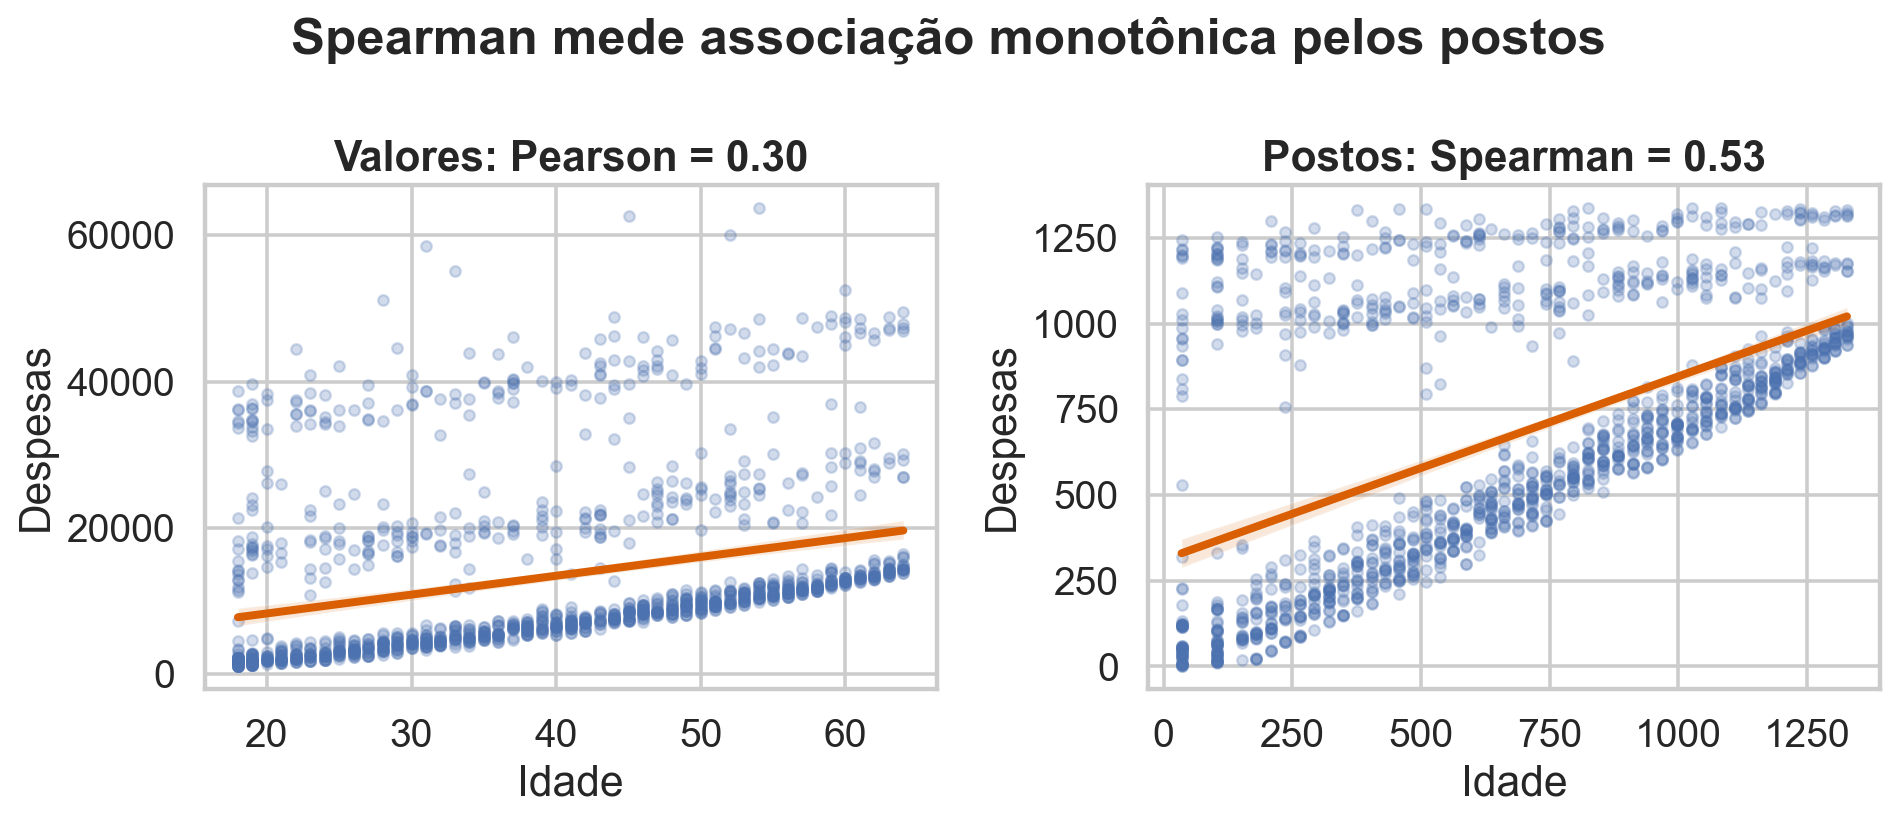

> **Interpretação**
>
> Spearman é maior porque a ordenação das despesas acompanha a idade
> melhor do que uma reta acompanha os valores em dólares. Isso não torna
> Spearman automaticamente superior: a escolha depende da pergunta sobre
> linearidade ou monotonicidade.

# 10. Sensibilidade a pontos influentes

In [ ]:
base = df.loc[df.smoker.eq("no"), ["bmi", "charges"]].sample(
    110, random_state=17
)
extra = pd.DataFrame({"bmi": [54], "charges": [63000]})
print("Sem ponto:", base.corr().iloc[0, 1])
print("Com ponto:", pd.concat([base, extra]).corr().iloc[0, 1])

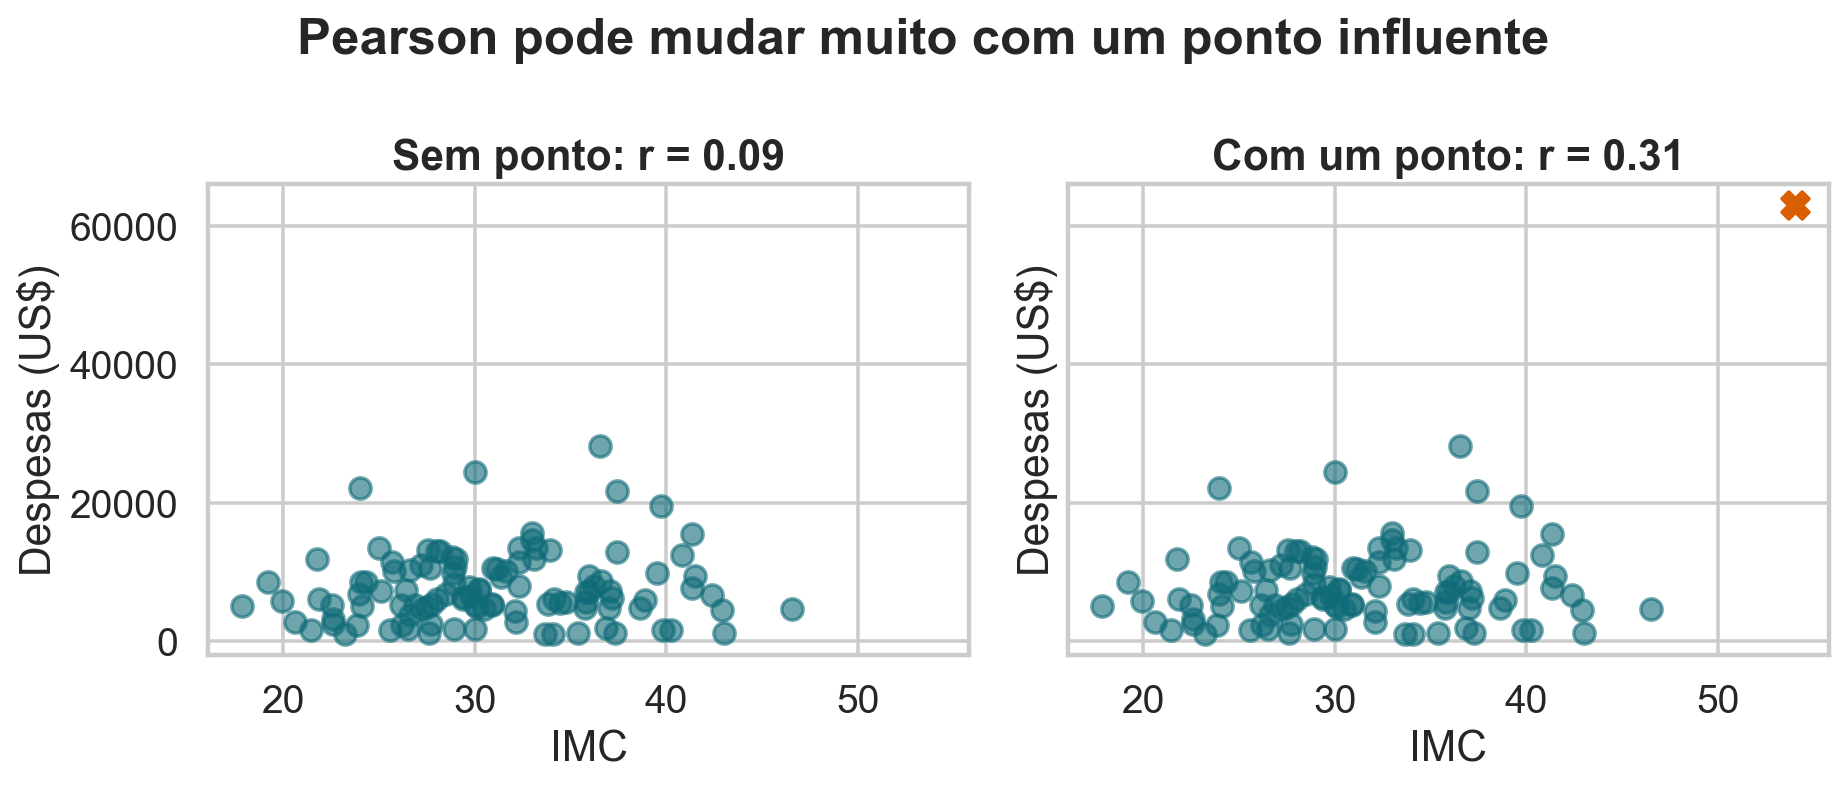

> **Interpretação**
>
> O ponto acrescentado está distante nas duas coordenadas e cria um
> produto de desvios muito grande. Pontos assim merecem investigação,
> mas não devem ser removidos apenas porque mudam a conclusão.

# 11. Restrição de amplitude

In [ ]:
full_r = df.age.corr(df.charges)
restricted = df[df.age.between(35, 45)]
restricted_r = restricted.age.corr(restricted.charges)
print(f"Faixa completa: {full_r:.3f}")
print(f"35–45 anos:    {restricted_r:.3f}")

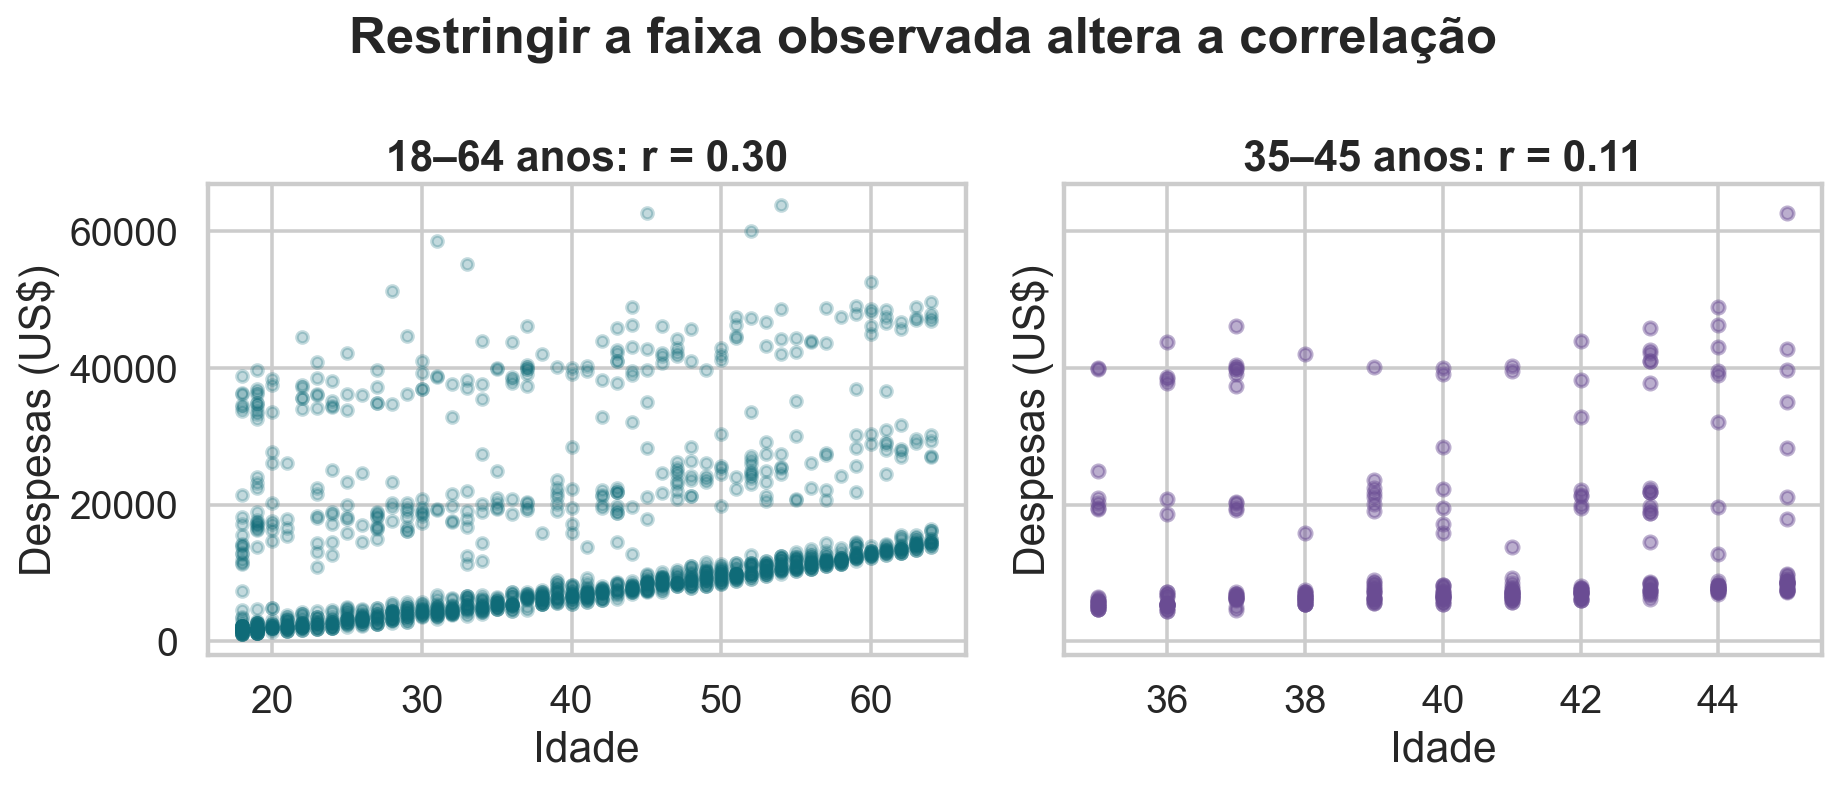

> **Interpretação**
>
> Dentro da faixa estreita há menos variação em idade. O valor de $r$
> descreve a população e o intervalo observados; ele não é uma constante
> universal que pode ser transportada sem considerar o desenho amostral.

# 12. Correlação marginal e condicional

In [ ]:
print("Global BMI-despesas:", df.bmi.corr(df.charges))
conditional = df.groupby("smoker").apply(
    lambda g: g.bmi.corr(g.charges)
)
conditional

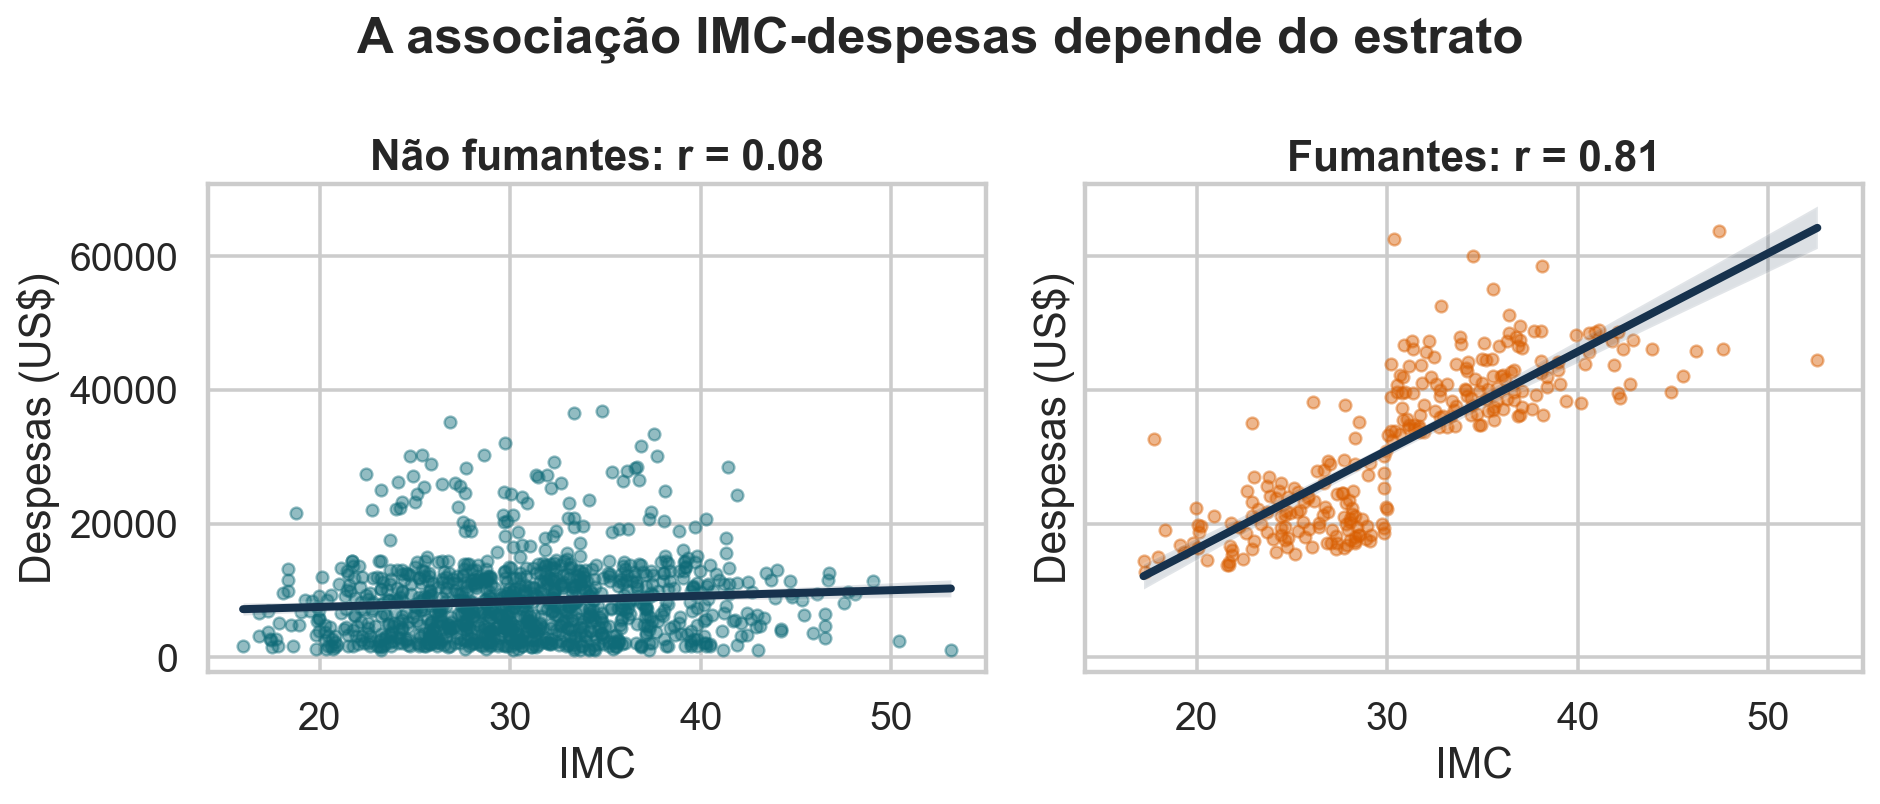

> **Interpretação**
>
> A correlação global é 0,20, mas vale aproximadamente 0,08 entre não
> fumantes e 0,81 entre fumantes. A associação do IMC com despesas
> depende fortemente do estrato; a média marginal esconde essa
> heterogeneidade.

## 12.1 Simpson, confundimento e condicionamento

O paradoxo de Simpson ocorre quando associações dentro dos estratos têm
uma direção, mas a associação agregada tem direção oposta. Ele é uma
forma extrema de mistura por composição dos grupos.

Condicionar não é um procedimento mecânico. Uma variável $Z$ pode ser:

- confundidora, por influenciar $X$ e $Y$;
- mediadora, por estar no caminho de $X$ para $Y$;
- colisora, por ser consequência de $X$ e $Y$.

Controlar confundidores pode reduzir viés; controlar mediadores ou
colisores pode mudar a pergunta ou criar viés. O conhecimento causal
orienta a escolha.

# 13. Incerteza da correlação

Na população, a correlação é $\rho$; na amostra, calculamos $r$. Para
obter um intervalo bootstrap, reamostramos **linhas completas**,
preservando cada par $(x_i,y_i)$.

In [ ]:
B = 4000
values = df[["age", "charges"]].to_numpy()
boot = np.empty(B)
for b in range(B):
    draw = values[rng.integers(0, len(values), len(values))]
    boot[b] = np.corrcoef(draw[:, 0], draw[:, 1])[0, 1]

ci = np.quantile(boot, [.025, .975])
print(f"IC bootstrap 95%: [{ci[0]:.3f}; {ci[1]:.3f}]")

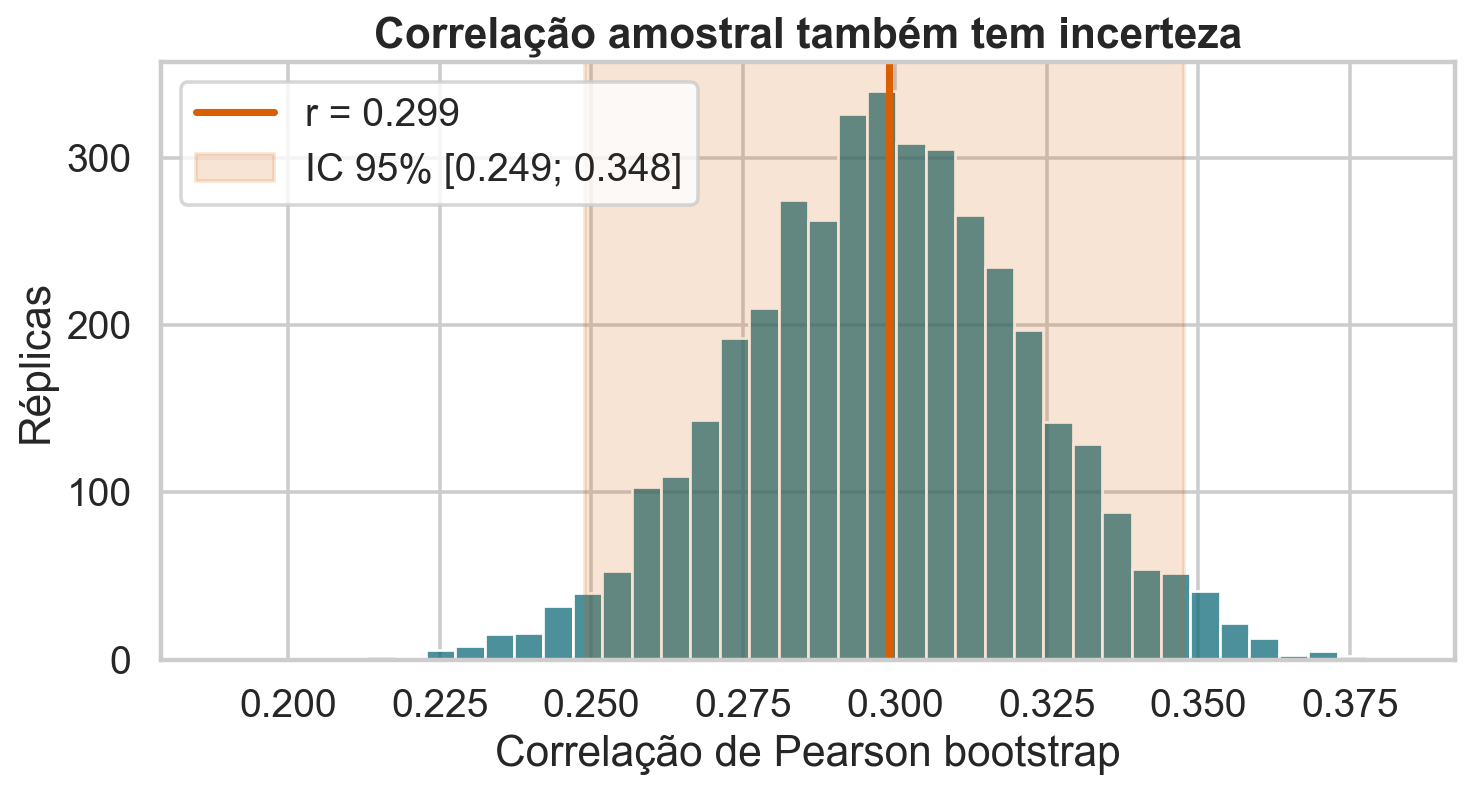

> **Interpretação**
>
> O intervalo de aproximadamente $[0,25;0,35]$ descreve a incerteza
> amostral sob uma reamostragem i.i.d. das pessoas observadas. Ele não
> incorpora viés de seleção, erro de medição ou dependência não
> modelada.

## 13.1 Testar $H_0:\rho=0$

Sob normalidade bivariada, a transformação de Fisher

$$
Z=\operatorname{arctanh}(r)
=\frac12\log\left(\frac{1+r}{1-r}\right)
$$

é aproximadamente normal, com erro-padrão $1/\sqrt{n-3}$. Aqui, $Z$ é a
correlação transformada, $r$ é a correlação amostral e $n$ é o tamanho
da amostra.

Uma alternativa é permutar uma variável em relação à outra para
representar ausência de associação, desde que a hipótese de
trocabilidade seja justificável. Rejeitar $H_0:\rho=0$ não demonstra
independência nem causalidade.

# 14. Correlação não é causalidade

Uma correlação entre $X$ e $Y$ é compatível com:

$$
X\to Y,\qquad Y\to X,\qquad Z\to X\text{ e }Z\to Y,
$$

além de seleção, tendências comuns e acaso. A base de seguros é
observacional; portanto, não identifica o efeito causal de fumar,
envelhecer ou alterar o IMC.

Também evite a falácia ecológica: uma correlação entre médias de estados
ou países não implica a mesma relação entre indivíduos.

# 15. Guia de decisão

Use **Pearson** quando a pergunta é sobre associação linear e o gráfico
não revela curvatura ou influência extrema dominante.

Use **Spearman** quando a pergunta é sobre ordenação monotônica, a
escala é ordinal ou uma transformação monotônica é plausível.

Em ambos os casos:

1.  descreva a base e a unidade observacional;
2.  visualize os dados;
3.  investigue grupos e pontos influentes;
4.  reporte coeficiente e incerteza;
5.  limite a conclusão à população e ao desenho;
6.  não use linguagem causal sem identificação causal.

# 16. Questões de revisão

1.  Observe a figura `quiz-correlacoes.png` dos slides e ordene as
    quatro nuvens por sinal e magnitude de Pearson antes de calcular.
2.  Por que dividir a covariância por $s_Xs_Y$ remove as unidades?
3.  Construa dois vetores dependentes com Pearson zero.
4.  Na relação monotônica curva do quiz, por que Spearman é maior que
    Pearson?
5.  Explique por que reamostrar `age` e `charges` separadamente seria
    errado no bootstrap.
6.  Por que a correlação IMC-despesas muda ao separar fumantes?
7.  Que informação a matriz de correlação não mostra?
8.  Refaça a análise usando `children` e explique por que o coeficiente
    é pequeno.

# Bibliografia

Para uma primeira leitura, use *Introduction to Modern Statistics* e o
material de *Computational and Inferential Thinking*. ISLR conecta
correlação à regressão; Freedman aprofunda interpretação e riscos em
estudos observacionais.

- Çetinkaya-Rundel e Hardin, *Introduction to Modern Statistics*,
  correlação e regressão linear.
- James et al., [*An Introduction to Statistical
  Learning*](https://www.statlearning.com/), capítulo 3.
- Freedman, Pisani e Purves, *Statistics*, correlação e estudos
  observacionais.
- VanderPlas, *Python Data Science Handbook*, visualização e exploração.
- [Computational and Inferential Thinking, seção
  15.1](https://inferentialthinking.com/chapters/15/1/Correlation.html).

Fonte dos dados: Kaggle,
`mosapabdelghany/medical-insurance-cost-dataset`, licença CC0.